In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device('cpu')
print(f"Using device: {device}")

PyTorch version: 2.12.0
CUDA available: False
Using device: cpu


In [2]:
np.random.seed(42)

N_CARDS = 5000        # 5000 unique cards
MIN_TX = 10           # minimum transaction history per card
MAX_TX = 50           # maximum transaction history per card
FRAUD_CARD_RATE = 0.15  # 15% of cards will commit fraud

merchant_list = ["Groceries", "Restaurant", "Electronics", "Travel",
                 "Online transfer", "ATM withdrawal", "Luxury goods", "Crypto exchange"]
location_list = ["Same city", "Different state", "International", "High-risk country"]
time_list     = ["Business hours", "Evening", "Early morning", "Late night (12–5am)"]
device_list   = ["Known device, matching IP", "Known device, new IP",
                 "New device, matching IP", "New device, new IP", "VPN / proxy detected"]

def generate_card_history(card_id, is_fraud_card):
    n_tx = np.random.randint(MIN_TX, MAX_TX)
    history = []

    # Normal behavior profile for this card
    normal_amount_mean  = np.random.uniform(50, 500)
    normal_amount_std   = normal_amount_mean * 0.3
    normal_merchant     = np.random.choice([0, 1, 2, 3], p=[0.4, 0.3, 0.2, 0.1])
    normal_location     = 0  # Same city
    normal_time         = np.random.choice([0, 1], p=[0.6, 0.4])
    normal_device       = 0  # Known device

    # Fraud break point — where behavior changes
    fraud_start = int(n_tx * np.random.uniform(0.6, 0.9)) if is_fraud_card else n_tx

    for i in range(n_tx):
        is_fraud_tx = is_fraud_card and i >= fraud_start

        if is_fraud_tx:
            amount   = np.random.uniform(2000, 20000)
            merchant = np.random.choice([4, 5, 6, 7], p=[0.2, 0.2, 0.2, 0.4])
            location = np.random.choice([2, 3], p=[0.4, 0.6])
            time     = np.random.choice([2, 3], p=[0.3, 0.7])
            device   = np.random.choice([3, 4], p=[0.4, 0.6])
            tx_24h   = np.random.randint(5, 15)
            card_age = np.random.randint(1, 6)
        else:
            amount   = max(1, np.random.normal(normal_amount_mean, normal_amount_std))
            merchant = np.random.choice([normal_merchant, (normal_merchant+1)%4], p=[0.8, 0.2])
            location = normal_location if np.random.random() > 0.05 else 1
            time     = normal_time if np.random.random() > 0.2 else (normal_time+1)%2
            device   = normal_device if np.random.random() > 0.05 else 1
            tx_24h   = np.random.randint(0, 3)
            card_age = np.random.randint(12, 60)

        history.append({
            "card_id":               card_id,
            "tx_index":              i,
            "amount":                round(amount, 2),
            "merchant_enc":          merchant,
            "location_enc":          location,
            "time_enc":              time,
            "device_enc":            device,
            "transactions_last_24h": tx_24h,
            "card_age_months":       card_age,
            "is_fraud":              int(is_fraud_tx),
            "is_fraud_card":         int(is_fraud_card)
        })

    return history

all_data = []
for card_id in range(N_CARDS):
    is_fraud_card = np.random.random() < FRAUD_CARD_RATE
    all_data.extend(generate_card_history(card_id, is_fraud_card))

df = pd.DataFrame(all_data)
print(f"Total transactions: {len(df)}")
print(f"Fraud cards: {df.groupby('card_id')['is_fraud_card'].first().sum()}")
print(f"Fraud transactions: {df['is_fraud'].sum()}")
print(f"Fraud rate: {df['is_fraud'].mean()*100:.2f}%")
df.head(10)

Total transactions: 146892
Fraud cards: 713
Fraud transactions: 5558
Fraud rate: 3.78%


,card_id,tx_index,amount,merchant_enc,location_enc,time_enc,device_enc,transactions_last_24h,card_age_months,is_fraud,is_fraud_card
0,0,0,96.09,2,0,1,0,0,13,0,0
1,0,1,127.61,2,0,1,0,0,23,0,0
2,0,2,133.43,2,1,0,0,1,58,0,0
3,0,3,115.54,2,0,0,0,0,18,0,0
4,0,4,108.68,2,0,0,0,0,19,0,0
5,0,5,170.22,2,0,0,0,1,17,0,0
6,0,6,145.39,2,0,0,0,1,42,0,0
7,0,7,77.14,3,0,1,1,0,27,0,0
8,0,8,143.02,2,0,0,0,0,26,0,0
9,0,9,197.83,2,1,0,0,2,22,0,0


In [3]:
# Add behavioral deviation features
# These capture how much each transaction deviates from that card's normal behavior

def add_behavioral_features(df):
    df = df.copy()
    
    # Rolling statistics per card — what is "normal" for this card
    df['amount_rolling_mean'] = df.groupby('card_id')['amount'].transform(
        lambda x: x.shift(1).rolling(window=5, min_periods=1).mean()
    )
    df['amount_rolling_std'] = df.groupby('card_id')['amount'].transform(
        lambda x: x.shift(1).rolling(window=5, min_periods=1).std().fillna(0)
    )
    
    # How many standard deviations is this amount from card's normal?
    df['amount_zscore'] = (df['amount'] - df['amount_rolling_mean']) / (df['amount_rolling_std'] + 1e-8)
    
    # Velocity — transactions in last N for this card
    df['velocity_3'] = df.groupby('card_id')['tx_index'].transform(
        lambda x: x.rolling(window=3, min_periods=1).count()
    )
    
    # Amount scaled
    scaler = StandardScaler()
    df['amount_scaled'] = scaler.fit_transform(df[['amount']])
    
    # Is this a new merchant for this card?
    df['merchant_deviation'] = (
        df['merchant_enc'] != df.groupby('card_id')['merchant_enc'].transform('first')
    ).astype(int)
    
    # Is this a new location for this card?
    df['location_deviation'] = (
        df['location_enc'] != df.groupby('card_id')['location_enc'].transform('first')
    ).astype(int)
    
    return df

df = add_behavioral_features(df)
print("Behavioral features added.")
print(f"Features: {df.columns.tolist()}")
print(f"\nSample z-scores for fraud transactions:")
print(df[df['is_fraud']==1]['amount_zscore'].describe())

Behavioral features added.
Features: ['card_id', 'tx_index', 'amount', 'merchant_enc', 'location_enc', 'time_enc', 'device_enc', 'transactions_last_24h', 'card_age_months', 'is_fraud', 'is_fraud_card', 'amount_rolling_mean', 'amount_rolling_std', 'amount_zscore', 'velocity_3', 'amount_scaled', 'merchant_deviation', 'location_deviation']

Sample z-scores for fraud transactions:
count    5558.000000
mean       30.087107
std       121.103357
min        -6.914115
25%        -0.155414
50%         0.768726
75%         1.990909
max      2509.101261
Name: amount_zscore, dtype: float64


In [4]:
SEQUENCE_LENGTH = 10  # look at last 10 transactions to predict the current one

feature_cols = [
    'amount_scaled', 'merchant_enc', 'location_enc', 'time_enc', 'device_enc',
    'transactions_last_24h', 'card_age_months', 'amount_zscore',
    'amount_rolling_mean', 'velocity_3', 'merchant_deviation', 'location_deviation'
]

INPUT_SIZE = len(feature_cols)
print(f"Input features per timestep: {INPUT_SIZE}")

def build_sequences(df, seq_len=SEQUENCE_LENGTH):
    sequences = []
    labels = []

    for card_id, group in df.groupby('card_id'):
        group = group.sort_values('tx_index').reset_index(drop=True)
        features = group[feature_cols].fillna(0).values
        targets  = group['is_fraud'].values

        # Slide a window across this card's history
        for i in range(seq_len, len(group)):
            seq = features[i-seq_len:i]   # last seq_len transactions
            label = targets[i]             # is current transaction fraud?
            sequences.append(seq)
            labels.append(label)

    return np.array(sequences, dtype=np.float32), np.array(labels, dtype=np.float32)

print("Building sequences (this takes ~30 seconds)...")
X_seq, y_seq = build_sequences(df)

print(f"\nSequence dataset shape: {X_seq.shape}")
print(f"Labels shape: {y_seq.shape}")
print(f"Fraud sequences: {y_seq.sum():.0f} ({y_seq.mean()*100:.2f}%)")

Input features per timestep: 12
Building sequences (this takes ~30 seconds)...

Sequence dataset shape: (96892, 10, 12)
Labels shape: (96892,)
Fraud sequences: 5441 (5.62%)


In [5]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train fraud rate: {y_train.mean()*100:.2f}%")
print(f"Test fraud rate:  {y_test.mean()*100:.2f}%")

# PyTorch Dataset
class FraudSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Handle class imbalance — weight the loss
fraud_count = int(y_train.sum())
legit_count = int(len(y_train) - fraud_count)
pos_weight  = torch.tensor([legit_count / fraud_count], dtype=torch.float32)
print(f"\nClass weight for fraud: {pos_weight.item():.2f}x")

# DataLoaders
train_dataset = FraudSequenceDataset(X_train, y_train)
test_dataset  = FraudSequenceDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")
print("✅ DataLoaders ready.")

Train: (77513, 10, 12) | Test: (19379, 10, 12)
Train fraud rate: 5.62%
Test fraud rate:  5.61%

Class weight for fraud: 16.81x

Train batches: 303
Test batches:  76
✅ DataLoaders ready.


In [6]:
class AttentionLayer(nn.Module):
    """
    Attention mechanism — learns WHICH timesteps in the
    sequence to focus on when making the fraud decision.
    This is the same core idea behind transformers and GPT.
    """
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Linear(hidden_size * 2, 1)

    def forward(self, lstm_output):
        # lstm_output: (batch, seq_len, hidden*2)
        attention_weights = torch.softmax(
            self.attention(lstm_output), dim=1
        )  # (batch, seq_len, 1)
        
        # Weighted sum of hidden states
        context = (attention_weights * lstm_output).sum(dim=1)
        return context, attention_weights.squeeze(-1)


class FraudLSTM(nn.Module):
    """
    Bidirectional LSTM with Attention for fraud detection.
    
    Bidirectional = reads the sequence both forward AND backward.
    This lets it understand context from both directions —
    a transaction looks more suspicious knowing what came after it.
    
    Attention = learns which past transactions matter most
    when scoring the current one.
    """
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.3):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        # Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True   # reads sequence forwards AND backwards
        )

        # Attention layer
        self.attention = AttentionLayer(hidden_size)

        # Batch normalization — stabilizes training
        self.batch_norm = nn.BatchNorm1d(hidden_size * 2)

        # Final classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        lstm_out, _ = self.lstm(x)
        # lstm_out: (batch, seq_len, hidden*2) — *2 because bidirectional

        # Apply attention
        context, attn_weights = self.attention(lstm_out)
        # context: (batch, hidden*2)

        # Normalize
        context = self.batch_norm(context)

        # Classify
        output = self.classifier(context)
        return output.squeeze(-1), attn_weights


# Initialize model
model = FraudLSTM(
    input_size=INPUT_SIZE,
    hidden_size=128,
    num_layers=2,
    dropout=0.3
)

# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model architecture:\n{model}")
print(f"\nTotal trainable parameters: {total_params:,}")
print("✅ LSTM model ready.")

Model architecture:
FraudLSTM(
  (lstm): LSTM(12, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): AttentionLayer(
    (attention): Linear(in_features=256, out_features=1, bias=True)
  )
  (batch_norm): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.15, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

Total trainable parameters: 560,002
✅ LSTM model ready.


In [8]:
# Loss and optimizer
criterion = nn.BCELoss(weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

EPOCHS = 20
best_auc = 0
best_model_state = None
train_losses = []
val_aucs = []

print("Starting training...\n")

for epoch in range(EPOCHS):
    # ── Training ──
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds, _ = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # ── Validation ──
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            preds, _ = model(X_batch)
            all_preds.extend(preds.numpy())
            all_labels.extend(y_batch.numpy())

    auc = roc_auc_score(all_labels, all_preds)
    val_aucs.append(auc)
    scheduler.step(avg_loss)

    # Save best model
    if auc > best_auc:
        best_auc = auc
        best_model_state = model.state_dict().copy()
        flag = " ← best"
    else:
        flag = ""

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss: {avg_loss:.4f} | AUC: {auc:.4f}{flag}")

print(f"\n✅ Training complete. Best AUC: {best_auc:.4f}")

# Load best model
model.load_state_dict(best_model_state)

Starting training...

Epoch 01/20 | Loss: 1.2570 | AUC: 0.9376 ← best
Epoch 02/20 | Loss: 0.8276 | AUC: 0.9400 ← best
Epoch 03/20 | Loss: 0.7698 | AUC: 0.9443 ← best
Epoch 04/20 | Loss: 0.7617 | AUC: 0.9446 ← best
Epoch 05/20 | Loss: 0.7369 | AUC: 0.9410
Epoch 06/20 | Loss: 0.7268 | AUC: 0.9456 ← best
Epoch 07/20 | Loss: 0.7248 | AUC: 0.9424
Epoch 08/20 | Loss: 0.7202 | AUC: 0.9458 ← best
Epoch 09/20 | Loss: 0.7299 | AUC: 0.9430
Epoch 10/20 | Loss: 0.7282 | AUC: 0.9402
Epoch 11/20 | Loss: 0.7099 | AUC: 0.9448
Epoch 12/20 | Loss: 0.7067 | AUC: 0.9374
Epoch 13/20 | Loss: 0.7090 | AUC: 0.9401
Epoch 14/20 | Loss: 0.7108 | AUC: 0.9426
Epoch 15/20 | Loss: 0.7073 | AUC: 0.9385
Epoch 16/20 | Loss: 0.7074 | AUC: 0.9405
Epoch 17/20 | Loss: 0.7270 | AUC: 0.9425
Epoch 18/20 | Loss: 0.7017 | AUC: 0.9439
Epoch 19/20 | Loss: 0.7028 | AUC: 0.9405
Epoch 20/20 | Loss: 0.7038 | AUC: 0.9397

✅ Training complete. Best AUC: 0.9458


<All keys matched successfully>

Optimal threshold: 1.0000

  LSTM FINAL EVALUATION
              precision    recall  f1-score   support

       Legit       0.99      1.00      1.00     18291
       Fraud       1.00      0.88      0.94      1088

    accuracy                           0.99     19379
   macro avg       1.00      0.94      0.97     19379
weighted avg       0.99      0.99      0.99     19379

ROC-AUC: 0.9397


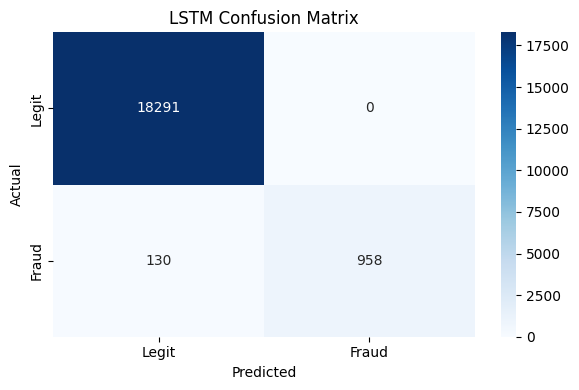

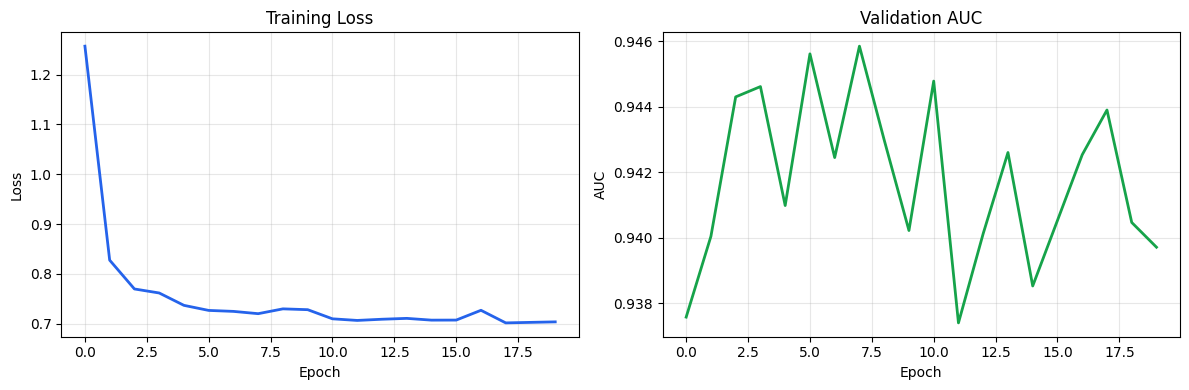


✅ LSTM model saved to artifacts/lstm_model.pt
✅ Confusion matrix saved
✅ Training curves saved


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import joblib

# Final evaluation
model.eval()
all_preds = []
all_labels = []
all_attn = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds, attn = model(X_batch)
        all_preds.extend(preds.numpy())
        all_labels.extend(y_batch.numpy())
        all_attn.extend(attn.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Best threshold using ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(all_labels, all_preds)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal threshold: {optimal_threshold:.4f}")

y_pred_binary = (all_preds >= optimal_threshold).astype(int)

print(f"\n{'='*50}")
print(f"  LSTM FINAL EVALUATION")
print(f"{'='*50}")
print(classification_report(all_labels, y_pred_binary, target_names=['Legit', 'Fraud']))
print(f"ROC-AUC: {roc_auc_score(all_labels, all_preds):.4f}")

# Confusion matrix
cm = confusion_matrix(all_labels, y_pred_binary)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit','Fraud'],
            yticklabels=['Legit','Fraud'])
plt.title('LSTM Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../artifacts/lstm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, color='#2563eb', linewidth=2)
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(val_aucs, color='#16a34a', linewidth=2)
ax2.set_title('Validation AUC')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUC')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../artifacts/lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Save model
torch.save({
    'model_state_dict': model.state_dict(),
    'input_size': INPUT_SIZE,
    'hidden_size': 128,
    'num_layers': 2,
    'optimal_threshold': optimal_threshold,
    'feature_cols': feature_cols,
    'best_auc': best_auc
}, '../artifacts/lstm_model.pt')

print(f"\n✅ LSTM model saved to artifacts/lstm_model.pt")
print(f"✅ Confusion matrix saved")
print(f"✅ Training curves saved")